# Mode 0 damper with RF Resonator


In [1]:
import numpy as np
import h5py as hp
import matplotlib.pyplot as plt
from tqdm import tqdm
from mbtrack2 import Synchrotron, Electron, Optics, LongitudinalMap, SynchrotronRadiation

from machine_data.demo import demo
from mbtrack2 import Bunch, LongitudinalMap, SynchrotronRadiation, RFCavity
from mbtrack2 import BunchSpectrumMonitor, BeamMonitor, Beam, plot_beamdata
nt=1000

d:\ProgramData\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


mbtrack2 version 0.8.0
--------------------------------------------------
If used in a publication, please cite mbtrack2 paper and the zenodo archive for the corresponding code version (and other papers for more specific features).
[1] A. Gamelin, W. Foosang, N. Yamamoto, V. Gubaidulin and R. Nagaoka, “mbtrack2”. Zenodo, Dec. 16, 2024. doi: 10.5281/zenodo.14418989.
[2] A. Gamelin, W. Foosang, and R. Nagaoka, “mbtrack2, a Collective Effect Library in Python”, presented at the 12th Int. Particle Accelerator Conf. (IPAC'21), Campinas, Brazil, May 2021, paper MOPAB070.




In [2]:
h = 20 # Harmonic number of the accelerator.
L = 100 # Ring circumference in [m].
E0 = 1.5e9 # Nominal (total) energy of the ring in [eV].
particle = Electron() # Particle considered.
ac = 1e-3 # Momentum compaction factor.
U0 = 200e3 # Energy loss per turn in [eV].
tau = np.array([1e-3, 1e-3, 2e-3]) # Horizontal, vertical and longitudinal damping times in [s].
tune = np.array([12.2, 15.3]) # Horizontal and vertical tunes.
emit = np.array([10e-9, 10e-12]) # Horizontal and vertical equilibrium emittance in [m.rad].
sigma_0 = 15e-12 # Natural bunch length in [s].
sigma_delta = 1e-3 # Equilibrium energy spread.
chro = [2.0, 3.0] # Horizontal and vertical (non-normalized) chromaticities.

In [3]:
local_beta = np.array([3, 2]) # Beta function at the tracking location.
local_alpha = np.array([0, 0]) # Alpha function at the tracking location.
local_dispersion = np.array([0, 0, 0, 0]) # Dispersion function and its derivative at the tracking location.
optics = Optics(local_beta=local_beta, local_alpha=local_alpha,
                  local_dispersion=local_dispersion)

In [4]:
ring = Synchrotron(h=h, optics=optics, particle=particle, L=L, E0=E0, ac=ac,
                   U0=U0, tau=tau, emit=emit, tune=tune,
                   sigma_delta=sigma_delta, sigma_0=sigma_0, chro=chro)

In [5]:
print("RF frequency = %.5f MHz"%(ring.f1/1e6))
print("Revolution frequency = %.5f MHz"%(ring.f0/1e6))

RF frequency = 59.95849 MHz
Revolution frequency = 2.99792 MHz


In [6]:
long = LongitudinalMap(ring) # define the LongitudinalMap element with the ring parameters
rad = SynchrotronRadiation(ring)

In [7]:
from mbtrack2 import Beam, CavityResonator, CavityMonitor, plot_cavitydata

In [8]:
import os

def restart(I0=0.001, tot_turns=500):
    fill_ptrn = np.zeros(ring.h)
    fill_ptrn[0:ring.h] = I0 / h
    mybeam = Beam(ring)
    mybeam.init_beam(fill_ptrn, mp_per_bunch=1)

    m = 1  # Harmonic number of the cavity
    Rs = 5e6  # Shunt impedance [Ohm]
    Q = 35e3
    QL = 5e3
    detune = -100e3  # Hz
    Ncav = 4
    MC = CavityResonator(ring, m, Rs, Q, QL, detune, Ncav=Ncav)

    MC.Vc = 1e6
    MC.theta = np.arccos(ring.U0 / MC.Vc)
    MC.set_optimal_detune(I0)
    MC.set_generator(I0)

    # 如果 MCmon 已存在，关闭并删除旧 HDF5 文件
    if 'bmon' in globals():
        try:
            globals()["bmon"].close()
        except Exception as e:
            print(f"Warning: MCmon close failed: {e}")

    if os.path.exists("save_0.hdf5"):
        try:
            os.remove("save_0.hdf5")
        except Exception as e:
            print(f"Warning: Failed to delete save.hdf5: {e}")

    total_size = int(tot_turns / 5)
    bmon = BeamMonitor(ring.h, 1, 1, nt, "save_0")

    return mybeam, MC, bmon

The HDF5 file to store data is not set.


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:31<00:00, 31.61it/s]


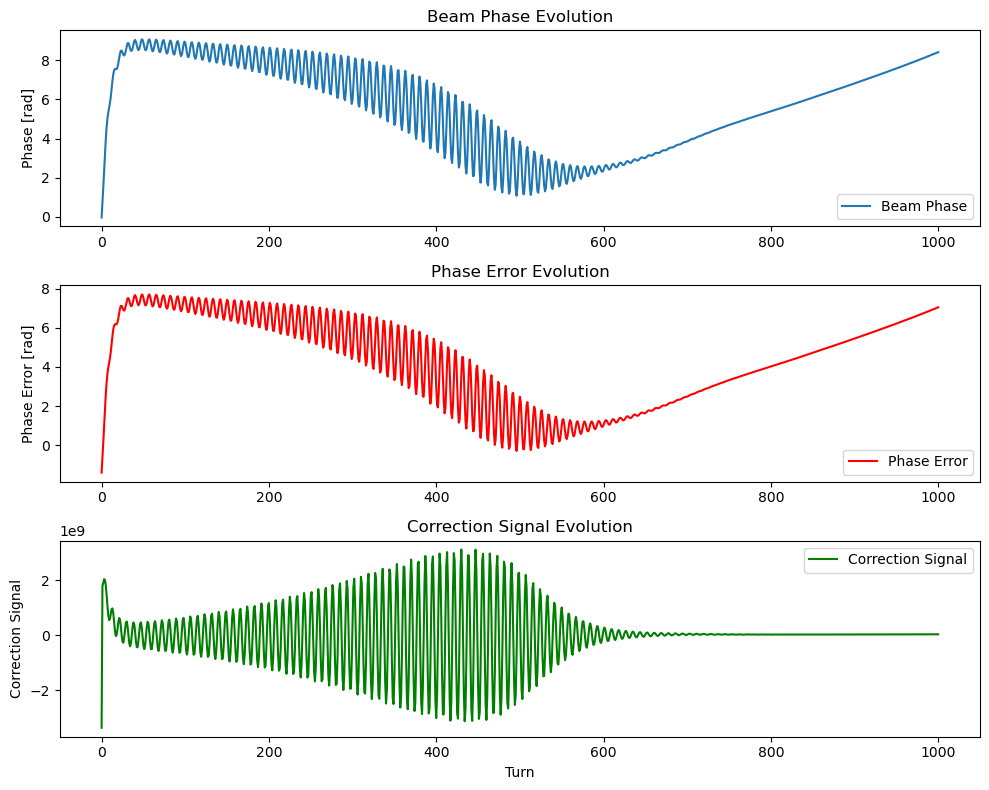

In [38]:
mybeam, MC, bmon = restart(I0=0.2, tot_turns=nt)
MC.init_phasor(mybeam)
from mbtrack2.tracking.rf import Mode0DamperLoop
# --- Setup damper parameters ---
# 创建 damper，自动传递同步频率
damper = Mode0DamperLoop(
    ring=ring,
    cav_res=MC,
    gain=[40, 0.0],  # Only proportional gain for damping, gain = 40, beam becomes unstable
    sample_num=10,    # Number of samples to average
    every=1,          # Update every turn
    delay=2,          # System delay in turns
    phase_shift=90.0  # Phase shift for damping
)

MC.feedback.append(damper)
  
for i in tqdm(range(nt+1)):
    long.track(mybeam)
    rad.track(mybeam)
    MC.track(mybeam)
    
    # Add external excitation

    for bunch in mybeam:
        bunch["tau"] += 1e-10

# Close monitor before next iteration
    bmon.track(mybeam)
bmon.close()
damper.plot_debug_data()

# without damper

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1001/1001 [00:31<00:00, 31.94it/s]


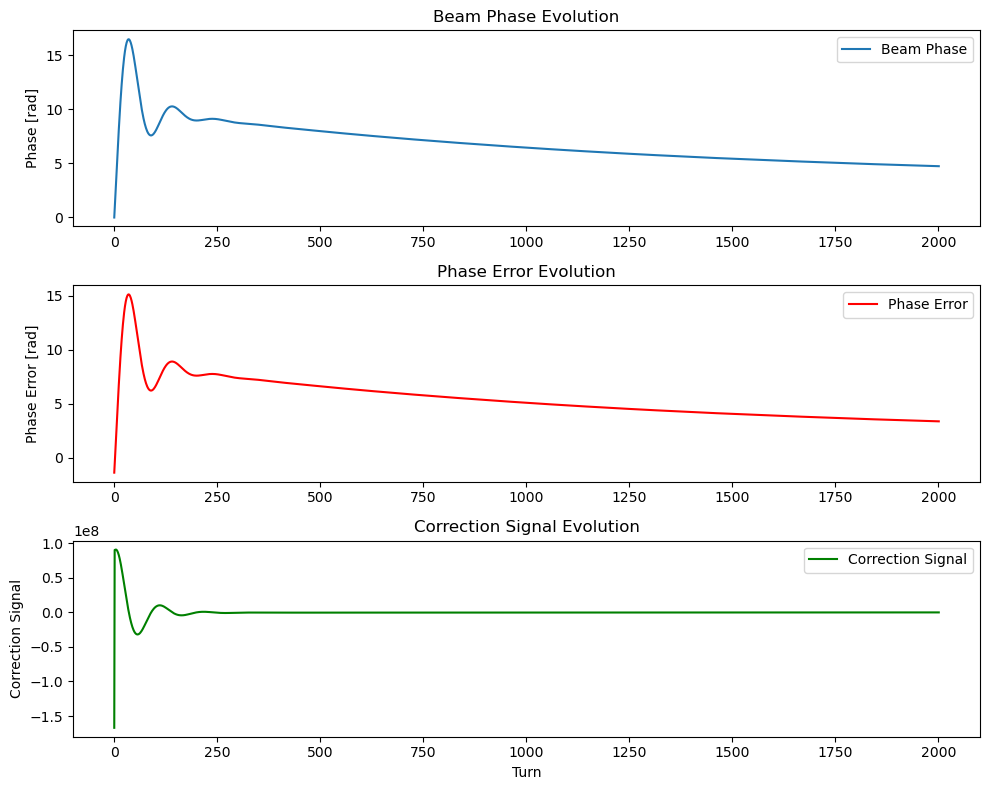

In [17]:
bmon = BeamMonitor(ring.h, 1, 1, nt, "save_0_1")
for i in tqdm(range(nt+1)):
    long.track(mybeam)
    rad.track(mybeam)
    MC.track(mybeam)
    
    # Add external excitation

    for bunch in mybeam:
        bunch["tau"] += 1e-10

# Close monitor before next iteration
    bmon.track(mybeam)
bmon.close()
damper.plot_debug_data()

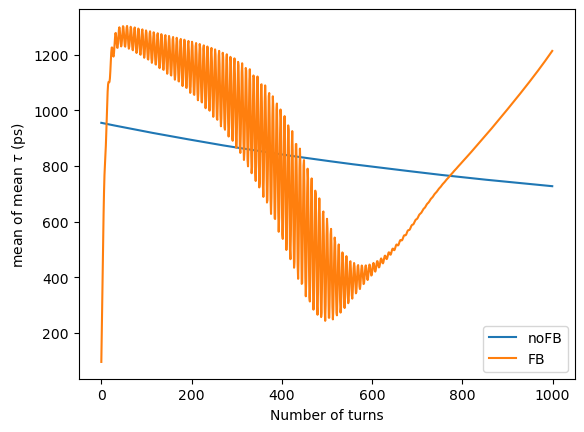

In [39]:
fig = plot_beamdata(["save_0_1" + ".hdf5", "save_0" + ".hdf5"],
              legend=["noFB","FB"])